<a href="https://colab.research.google.com/github/dilekmirac/goruntu_isleme/blob/main/hafta2_g%C3%B6rev4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import torch

print(f"OpenCV Versiyonu: {cv2.__version__}")
print(f"CUDA Kullanılabilir mi (PyTorch/GPU): {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"Aktif GPU Modeli: {torch.cuda.get_device_name(0)}")

OpenCV Versiyonu: 5.0.0
CUDA Kullanılabilir mi (PyTorch/GPU): True
Aktif GPU Modeli: Tesla T4


       PARALEL HİSTOGRAM RAPORU
Resim Boyutu            : 678x452 (306456 piksel)
Histogram Toplam Piksel : 306456
Hesaplama Süresi        : 0.1941 saniye
Doğrulama               : BAŞARILI


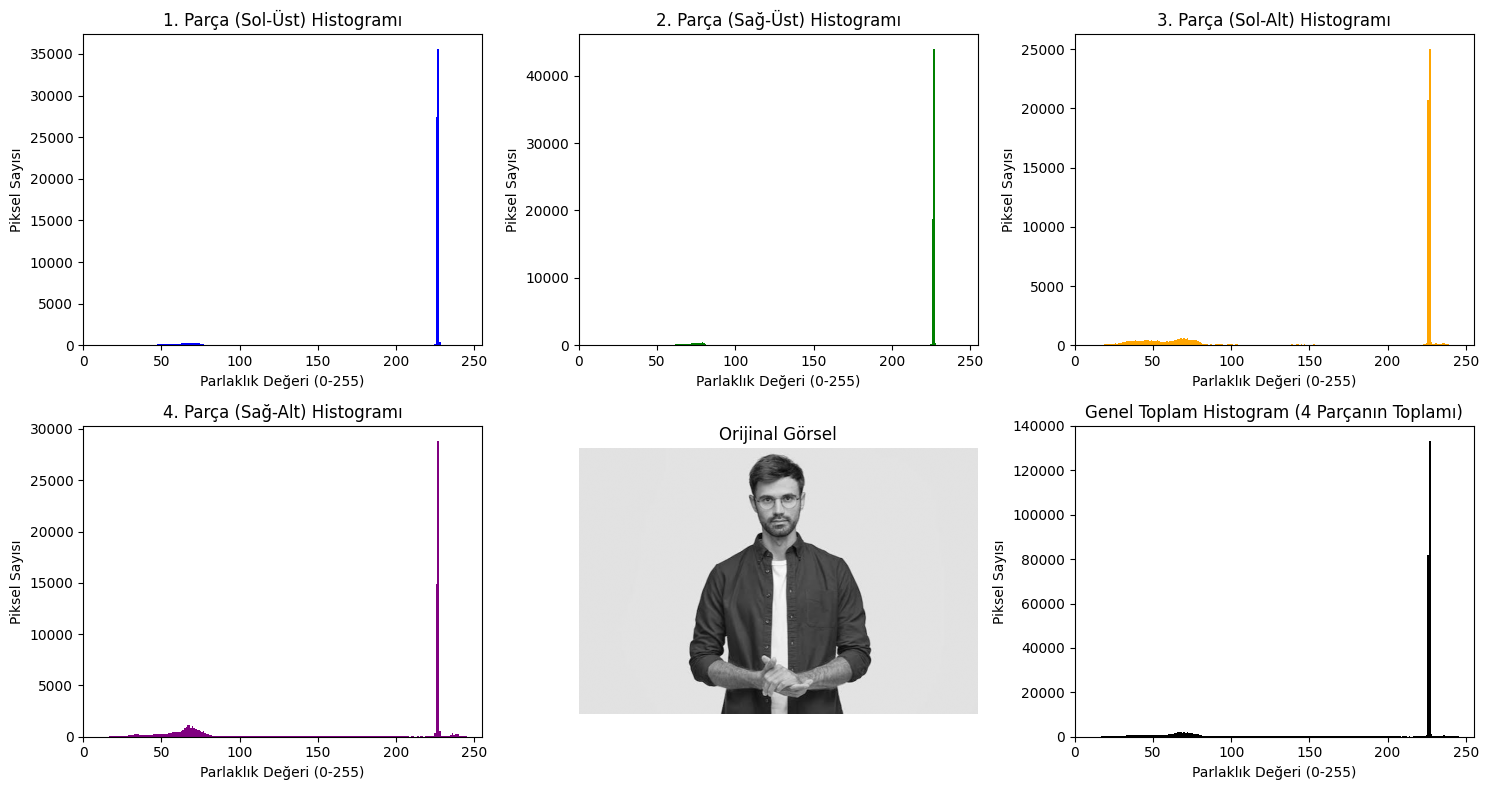

In [ ]:
import cv2
import numpy as np
import time
from multiprocessing import Pool
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. Çekirdeklerin çalıştıracağı histogram hesaplama fonksiyonu
# -------------------------------------------------------------------------
def roi_histogram_hesapla(roi):
    """
    Kendisine gelen ROI parçasındaki pikselleri tek tek gezer ve
    0-255 arasındaki her parlaklık değerinin frekansını (adetini) sayar.
    """
    h, w = roi.shape
    # 0'dan 255'e kadar 256 elemanlı boş bir sayaç dizisi
    yerel_histogram = np.zeros(256, dtype=int)

    # Satır ve sütunları gezerek sayaçları artır
    for i in range(h):
        for j in range(w):
            piksel_degeri = int(roi[i, j])
            yerel_histogram[piksel_degeri] += 1

    return yerel_histogram

# -------------------------------------------------------------------------
# 2. Ana Çalışma Bloğu
# -------------------------------------------------------------------------
if __name__ == '__main__':
    img_bgr = cv2.imread('insan.jpg')
    if img_bgr is None:
        raise FileNotFoundError("'insan.jpg' bulunamadı! Sol panele resmi yükleyin.")

    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    yukseklik, genislik = img_gray.shape
    toplam_piksel = yukseklik * genislik

    # 1. Resmi tam ortadan 4 eşit ROI parçasına böl
    orta_y = yukseklik // 2
    orta_x = genislik // 2

    roiler = [
        img_gray[0:orta_y, 0:orta_x],          # Sol-Üst
        img_gray[0:orta_y, orta_x:genislik],   # Sağ-Üst
        img_gray[orta_y:yukseklik, 0:orta_x],  # Sol-Alt
        img_gray[orta_y:yukseklik, orta_x:genislik] # Sağ-Alt
    ]

    # 2. 4 Çekirdekle paralel olarak her parçanın histogramını hesapla
    baslangic = time.perf_counter()
    with Pool(processes=4) as pool:
        parca_histogramlari = pool.map(roi_histogram_hesapla, roiler)
    bitis = time.perf_counter()

    # 3. 4 parçanın histogramını toplayarak tüm resmin genel histogramını elde et
    genel_histogram = (parca_histogramlari[0] +
                       parca_histogramlari[1] +
                       parca_histogramlari[2] +
                       parca_histogramlari[3])

    # 4. Doğrulama ve Rapor
    sayilan_toplam_piksel = np.sum(genel_histogram)
    print("=" * 45)
    print("       PARALEL HİSTOGRAM RAPORU")
    print("=" * 45)
    print(f"Resim Boyutu            : {genislik}x{yukseklik} ({toplam_piksel} piksel)")
    print(f"Histogram Toplam Piksel : {sayilan_toplam_piksel}")
    print(f"Hesaplama Süresi        : {bitis - baslangic:.4f} saniye")
    print(f"Doğrulama               : {'BAŞARILI' if toplam_piksel == sayilan_toplam_piksel else 'HATALI'}")
    print("=" * 45)

    # 5. Görselleştirme: 4 parçanın histogramı + Genel Toplam Histogram
    plt.figure(figsize=(15, 8))

    etiketler = ['1. Parça (Sol-Üst)', '2. Parça (Sağ-Üst)', '3. Parça (Sol-Alt)', '4. Parça (Sağ-Alt)']
    renkler = ['blue', 'green', 'orange', 'purple']

    # 4 parçanın bağımsız histogramlarını çiz
    for idx in range(4):
        plt.subplot(2, 3, idx + 1)
        plt.bar(range(256), parca_histogramlari[idx], color=renkler[idx], width=1.0)
        plt.title(f"{etiketler[idx]} Histogramı")
        plt.xlabel("Parlaklık Değeri (0-255)")
        plt.ylabel("Piksel Sayısı")
        plt.xlim([0, 255])

    # Orijinal görsel
    plt.subplot(2, 3, 5)
    plt.imshow(img_gray, cmap='gray')
    plt.title("Orijinal Görsel")
    plt.axis('off')

    # Birleştirilmiş nihai genel histogram
    plt.subplot(2, 3, 6)
    plt.bar(range(256), genel_histogram, color='black', width=1.0)
    plt.title("Genel Toplam Histogram (4 Parçanın Toplamı)")
    plt.xlabel("Parlaklık Değeri (0-255)")
    plt.ylabel("Piksel Sayısı")
    plt.xlim([0, 255])

    plt.tight_layout()
    plt.show()

In [ ]:
import cv2
import numpy as np
import time
from multiprocessing import Pool

def roi_histogram_hesapla(roi):
    h, w = roi.shape
    yerel_hist = np.zeros(256, dtype=int)
    for i in range(h):
        for j in range(w):
            yerel_hist[int(roi[i, j])] += 1
    return yerel_hist

if __name__ == '__main__':
    img_bgr = cv2.imread('insan.jpg')
    if img_bgr is None:
        raise FileNotFoundError("'insan.jpg' bulunamadı!")

    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # -------------------------------------------------------------
    # İŞTE KİLİT NOKTA: Resmi işlemcinin hissedebileceği boyuta çıkarıyoruz
    # -------------------------------------------------------------
    img_gray = cv2.resize(img_gray, (3000, 3000))
    h, w = img_gray.shape
    print(f"Test Görsel Boyutu: {w}x{h} ({w*h:,} piksel)")

    # 4 ROI parçası
    orta_y, orta_x = h // 2, w // 2
    roiler = [
        img_gray[0:orta_y, 0:orta_x],
        img_gray[0:orta_y, orta_x:w],
        img_gray[orta_y:h, 0:orta_x],
        img_gray[orta_y:h, orta_x:w]
    ]

    # 1. Tek Çekirdek Sıralı
    basla_tek = time.perf_counter()
    hist_tek = [roi_histogram_hesapla(r) for r in roiler]
    toplam_hist_tek = hist_tek[0] + hist_tek[1] + hist_tek[2] + hist_tek[3]
    bitir_tek = time.perf_counter()
    sure_tek = bitir_tek - basla_tek

    # 2. 4 Çekirdek Paralel
    basla_paralel = time.perf_counter()
    with Pool(processes=4) as pool:
        hist_paralel = pool.map(roi_histogram_hesapla, roiler)
    toplam_hist_paralel = hist_paralel[0] + hist_paralel[1] + hist_paralel[2] + hist_paralel[3]
    bitir_paralel = time.perf_counter()
    sure_paralel = bitir_paralel - basla_paralel

    # Rapor
    hizlanma = sure_tek / sure_paralel if sure_paralel > 0 else 0

    print("=" * 50)
    print("         PERFORMANS VE HIZLANMA RAPORU")
    print("=" * 50)
    print(f"Tek Çekirdek Süresi       : {sure_tek:.4f} saniye")
    print(f"4 Çekirdek Paralel Süresi : {sure_paralel:.4f} saniye")
    print(f"Hızlanma Oranı (Speedup)  : {hizlanma:.2f} kat hızlandı!")
    print("=" * 50)

Test Görsel Boyutu: 3000x3000 (9,000,000 piksel)
         PERFORMANS VE HIZLANMA RAPORU
Tek Çekirdek Süresi       : 4.9086 saniye
4 Çekirdek Paralel Süresi : 4.8061 saniye
Hızlanma Oranı (Speedup)  : 1.02 kat hızlandı!
